<a href="https://colab.research.google.com/github/seagrinch/embark-scratch-notebooks/blob/main/scratch_usecase_argo_salinity_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Use Case: BCO-DMO_Argo salinity scratch notebook

Use Case document: https://docs.google.com/document/d/1y54G4L41E79BVHgoV6qy1KY1ODrBKHPI/edit

## Usecase Goal:

The CI user will (find), access, and use data from external sources to plot salinity by depth over a several-year time period for a location in which some of the profiles were collected by ship-based CTD/rosette casts and others were sensed by Argo float(s).

## Sources for this scratch
notebook:

* OOI Irminger Discrete Water Samples
Based on Source Notebook link: https://github.com/WHOIGit/ooi-on-bco-dmo/blob/main/notebooks/0-OOI-Irminger-discrete-sample-article-figures.ipynb by Andrew Reed ([reedan88](https://github.com/reedan88))
*  ARGO profiles near OOI Irminger Sea Profiler https://github.com/seagrinch/embark-scratch-notebooks/blob/main/argo-irminger.ipynb by Sage Lichtenwalner ([seagrinch](https://github.com/seagrinch))

This notebook combines the two data sources used in the above notebook, borrows documentation and example loading and plotting.  Additional data combintation of data streams and co-located plotting.

# Setup

In [1]:
#install libraries directly into the current kernel's environment if dependency not found
try:
    import argopy
except ImportError:
    %pip install -q argopy

try:
    import cmocean.cm as cmo
except ImportError:
    %pip install -q cmocean


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.5/202.5 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 79.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 27.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.2.0 which is incompatible.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.2.0 which is incompati

In [2]:
# Import modules
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from matplotlib.dates import AutoDateLocator, AutoDateFormatter
import cmocean.cm as cmo # colormaps for commonly-used oceanographic variables

In [ ]:
# print(mpl.__version__) # if plot cell results in error check version of matplotlib

# DATASET 1 - Discrete Salinity

## Dataset 1: Find Data

Find discrete Salinity data in area (Irminger Sea) and time of interest (2018-2021).

Search with term "Irminger Sea discrete water sampling"

### Method 1:
Can [search BCO-DMO www.bco-dmo.org](https://www.bco-dmo.org/search?query=%7E%27Irminger*20Sea*20discrete*20water*20sampling)

### Method 2:
Can also search for dataset through ERDDAP server to get to https://erddap.bco-dmo.org/erddap/tabledap/bcodmo_dataset_911407_v1.html

### Method 3:
Google Data Search or some other general search?? Good idea? Bad idea? [Google Data Search "Irminger Sea discrete water sampling"](https://datasetsearch.research.google.com/search?src=0&query=Irminger%20Sea%20discrete%20water%20sampling&docid=L2cvMTF4a185NHR5Zg%3D%3D) gives the dataset we are looking for and links the ERDDAP page for it

Normal google search gets you there too "Irminger Sea discrete water sampling" https://www.bco-dmo.org/dataset/911407

## Found dataset of interest
All methods get you data for
Dataset: https://www.bco-dmo.org/dataset/911407 (access directly or in ERDDAP)
ERDDAP https://erddap.bco-dmo.org/erddap/info/bcodmo_dataset_911407_v1/index.html

## See if our desired space and time is in the dataset
* Target bounding box: 59.5 to 60.5 N, 40 to 39 W
* Time: 2018-2021

[Subset link](https://erddap.bco-dmo.org/erddap/tabledap/bcodmo_dataset_911407_v1.graph?longitude%2Clatitude%2C&latitude%3E51.12&latitude%3C85.68&longitude%3E-52.48&longitude%3C-17.92&Start_Time%3E=%222018%22&Start_Time%3C=%222021%22&.draw=markers&.marker=5%7C5&.color=0x000000&.colorBar=%7C%7C%7C%7C%7C&.bgColor=0xffccccff)

<div align="center">
  <img src="https://erddap.bco-dmo.org/erddap/tabledap/bcodmo_dataset_911407_v1.png?longitude,latitude&latitude%3E40.122&latitude%3C86.998&longitude%3E-62.668&longitude%3C-15.792&Start_Time%3E=%222018%22&Start_Time%3C=%222021%22&.draw=markers&.marker=5%7C5&.color=0x000000&.colorBar=%7C%7C%7C%7C%7C&.bgColor=0xffccccff" alt="Description">
</div>

## Dataset 1: Inspect data/metadata for context


Inspect the dataset landing page metadata for context for your analysis.  Review the methodology, data processing information, and what the columns represent by looking at the "Parameters" section. Under Data Files you can also preview what the tables look like.

* Dataset: OOI Global Irminger Sea Array CTD and Discrete Water Sampling Data from Mooring Overturning Cruises in the Irminger Sea from 2014-2023 (OOI Cruise Data project)
* **Dataset Landing Page: https://www.bco-dmo.org/dataset/911407**


### Check for Related Data and Broader Program/Study context

See if there is a "Related Datasets" section listed on the Dataset Landing Page

Check out the "Project" listed on the BCO-DMO Dataset Landing Page, it may have other datasets of interest. https://www.bco-dmo.org/project/905736
* The NSF Ocean Observatories Initiative (OOI) provides Discrete CTD and Water Sampling Cruise Data for each Array as a dataset.

You can also find out more about OOI at their homepage https://oceanobservatories.org/

### Review the data license

Check the license to make sure your intended use is allowed. The license may affect what license you can apply to any dataset you create from it. You may also need to credit the original authors.

You can see in the "Cite Dataset" box (top right of page) it says:

Terms of Use:
*"This dataset is licensed under [Creative Commons Attribution 4.0](https://creativecommons.org/licenses/by/4.0/)."*

## Dataset 1: Access Data

### Load Discrete Salinity from OOI CTD


To access the data in comma separated variable (CSV) format, one can either:
1. Access the File through the URL at ERDDAP > Files (shown below)
2. Generate a URL using the [ERDDAP Data Access Form](https://erddap.bco-dmo.org/erddap/tabledap/bcodmo_dataset_911407_v1.html)
      - If using the ERDDAP Data Access Form, file type .csvp provides a single header row.
      - If using the ERDDAP Data Access Form, one can subset (e.g., select variables of interest) prior to loading the data.

In [3]:
# ERDDAP link to the public dataset CSV
erddap_url = "https://erddap.bco-dmo.org/erddap/files/bcodmo_dataset_911407_v1/911407_v1_ooi_irminger_sea_discrete_water_sampling_data.csv"

# Load the OOI data into a dataframe
ooi_irm = pd.read_csv(erddap_url)

# Call head() to check that the data was imported correctly
ooi_irm.head()

,Cruise,Station,Target_Asset,Start_Latitude,Start_Longitude,Start_Time,Cast,Cast_Flag,Bottom_Depth_at_Start_Position,CTD_File,...,Discrete_pH_Replicate_Flag,Calculated_Alkalinity,Calculated_DIC,Calculated_pCO2,Calculated_pH,Calculated_CO2aq,Calculated_Bicarb,Calculated_CO3,Calculated_Omega_C,Calculated_Omega_A
0,KN221-04,1,Test Site #1,62.107,-31.381667,2014-09-08T11:39:06.000Z,1,*0000000000000100,NaN,KN22104001.hex,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,KN221-04,1,Test Site #1,62.107,-31.381667,2014-09-08T11:39:06.000Z,1,*0000000000000100,NaN,KN22104001.hex,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,KN221-04,1,Test Site #1,62.107,-31.381667,2014-09-08T11:39:06.000Z,1,*0000000000000100,NaN,KN22104001.hex,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,KN221-04,1,Test Site #1,62.107,-31.381667,2014-09-08T11:39:06.000Z,1,*0000000000000100,NaN,KN22104001.hex,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,KN221-04,1,Test Site #1,62.107,-31.381667,2014-09-08T11:39:06.000Z,1,*0000000000000100,NaN,KN22104001.hex,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### List available parameters
Convert relevant parameters to datetime if needed

In [4]:
print(ooi_irm.columns)

Index(['Cruise', 'Station', 'Target_Asset', 'Start_Latitude',
       'Start_Longitude', 'Start_Time', 'Cast', 'Cast_Flag',
       'Bottom_Depth_at_Start_Position', 'CTD_File', 'CTD_File_Flag',
       'Niskin_Bottle_Position', 'Niskin_Flag', 'CTD_Bottle_Closure_Time',
       'CTD_Pressure', 'CTD_Pressure_Flag', 'CTD_Depth', 'CTD_Latitude',
       'CTD_Longitude', 'CTD_Temperature_1', 'CTD_Temperature_1_Flag',
       'CTD_Temperature_2', 'CTD_Temperature_2_Flag', 'CTD_Conductivity_1',
       'CTD_Conductivity_1_Flag', 'CTD_Conductivity_2',
       'CTD_Conductivity_2_Flag', 'CTD_Salinity_1', 'CTD_Salinity_2',
       'CTD_Oxygen', 'CTD_Oxygen_Flag', 'CTD_Oxygen_Saturation',
       'CTD_Fluorescence', 'CTD_Fluorescence_Flag', 'CTD_Beam_Attenuation',
       'CTD_Beam_Transmission', 'CTD_Transmissometer_Flag', 'CTD_pH',
       'CTD_pH_Flag', 'Discrete_Oxygen', 'Discrete_Oxygen_Flag',
       'Discrete_Oxygen_Replicate_Flag', 'Discrete_Chlorophyll',
       'Discrete_Phaeopigment', 'Discrete_Fo_

In [5]:
# Convert the CTD Bottle Closure Time to a datetime data type
ooi_irm["CTD_Bottle_Closure_Time"] = pd.to_datetime(ooi_irm["CTD_Bottle_Closure_Time"], yearfirst=True, utc=True)
ooi_irm.dtypes["CTD_Bottle_Closure_Time"]

datetime64[ns, UTC]

## 8) Dataset 1: Transform data (if needed)

### Apply QC flags
For functions to interpret OOI discrete sample CTD flags to QARTOD QC-flags please see bottles.py file in https://github.com/oceanobservatories/ooi-data-explorations. For your convience, the module has also been included in this repository.

In [6]:
# display unique Discrete Sample flags
# ooi_irm.Discrete_Oxygen_Flag.unique() # display unique one column
pd.unique(ooi_irm[["Discrete_Oxygen_Flag", "Discrete_Salinity_Flag", "Discrete_Nutrients_Flag"]].values.ravel('K')) # display unique multiple columns

array([nan, '*0000000000000100', '*0000000000000010', '*0000000000000101',
       '*0000000000001001'], dtype=object)

In [7]:
# Assign "Acceptable" flags to QARTOD
flag1 = "*0000000000000100" # Good 1 in Bit Position 2 (i.e., 3rd from right)
flag2 = "*0000000000000101" # this example had 2 unique "Acceptable" flags

ooi_irm.loc[ooi_irm.Discrete_Oxygen_Flag == flag1, 'Discrete_Oxygen_Flag'] = 1       # assign QARTOD Good
ooi_irm.loc[ooi_irm.Discrete_Oxygen_Flag == flag2, 'Discrete_Oxygen_Flag'] = 1       # assign QARTOD Good
ooi_irm.loc[ooi_irm.Discrete_Salinity_Flag == flag1, 'Discrete_Salinity_Flag'] = 1   # assign QARTOD Good
ooi_irm.loc[ooi_irm.Discrete_Salinity_Flag == flag2, 'Discrete_Salinity_Flag'] = 1   # assign QARTOD Good
ooi_irm.loc[ooi_irm.Discrete_Nutrients_Flag == flag1, 'Discrete_Nutrients_Flag'] = 1 # assign QARTOD Good
ooi_irm.loc[ooi_irm.Discrete_Nutrients_Flag == flag2, 'Discrete_Nutrients_Flag'] = 1 # assign QARTOD Good

# Display unique Discrete Sample flags
pd.unique(ooi_irm[["Discrete_Oxygen_Flag", "Discrete_Salinity_Flag", "Discrete_Nutrients_Flag"]].values.ravel('K')) # display unique multiple columns


array([nan, 1, '*0000000000000010', '*0000000000001001'], dtype=object)

In [8]:
# Subset Data Frame to Discrete Samples with Acceptable flags
irm_qc = ooi_irm.query("Discrete_Oxygen_Flag==1 | Discrete_Salinity_Flag==1 | Discrete_Nutrients_Flag==1")
print(f"This subset of Discrete Samples with Acceptable flags reduced the total data points from {len(ooi_irm)} to {len(irm_qc)}")

This subset of Discrete Samples with Acceptable flags reduced the total data points from 1937 to 1174


In [9]:
# For indexing multi-panel plots with matplotlib
flag_oxy = irm_qc["Discrete_Oxygen_Flag"]==1
flag_sal = irm_qc["Discrete_Salinity_Flag"]==1
flag_ntr = irm_qc["Discrete_Nutrients_Flag"]==1

In [10]:
#  Subset to just the area and time of interest
# Bounds
LON_MIN, LON_MAX = -40, -39
LAT_MIN, LAT_MAX = 59.5, 60.5
TIME_MIN, TIME_MAX = "2018-01-01", "2021-12-31"

# Ensure we are not working on a view
irm_qc = irm_qc.copy()

irm_qc.loc[:, "CTD_Bottle_Closure_Time"] = pd.to_datetime(
    irm_qc["CTD_Bottle_Closure_Time"], yearfirst=True, utc=True, errors="coerce"
)

tmin = pd.to_datetime(TIME_MIN, utc=True)
tmax = pd.to_datetime(TIME_MAX, utc=True)

ooi_subset = irm_qc.loc[
    (irm_qc["CTD_Bottle_Closure_Time"] >= tmin) &
    (irm_qc["CTD_Bottle_Closure_Time"] <= tmax) &
    (irm_qc["Start_Latitude"] >= LAT_MIN) &
    (irm_qc["Start_Latitude"] <= LAT_MAX) &
    (irm_qc["Start_Longitude"] >= LON_MIN) &
    (irm_qc["Start_Longitude"] <= LON_MAX)
].copy().reset_index(drop=True)

ooi_subset

,Cruise,Station,Target_Asset,Start_Latitude,Start_Longitude,Start_Time,Cast,Cast_Flag,Bottom_Depth_at_Start_Position,CTD_File,...,Discrete_pH_Replicate_Flag,Calculated_Alkalinity,Calculated_DIC,Calculated_pCO2,Calculated_pH,Calculated_CO2aq,Calculated_Bicarb,Calculated_CO3,Calculated_Omega_C,Calculated_Omega_A
0,AR30-03,5,SUMO,59.940500,-39.523,2018-06-08T18:14:14.000Z,5,*0000000000000100,2702.0,D:\Data\ar30-03005.hex,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AR30-03,5,SUMO,59.940500,-39.523,2018-06-08T18:14:14.000Z,5,*0000000000000100,2702.0,D:\Data\ar30-03005.hex,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AR30-03,5,SUMO,59.940500,-39.523,2018-06-08T18:14:14.000Z,5,*0000000000000100,2702.0,D:\Data\ar30-03005.hex,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AR30-03,5,SUMO,59.940500,-39.523,2018-06-08T18:14:14.000Z,5,*0000000000000100,2702.0,D:\Data\ar30-03005.hex,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AR30-03,5,SUMO,59.940500,-39.523,2018-06-08T18:14:14.000Z,5,*0000000000000100,2702.0,D:\Data\ar30-03005.hex,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,AR60-01,012,FLMB,59.726333,-39.333,2021-08-17T21:18:48.000Z,012,*0000000000000100,2821.0,ar60-1_012.hex,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
284,AR60-01,012,FLMB,59.726333,-39.333,2021-08-17T21:18:48.000Z,012,*0000000000000100,2821.0,ar60-1_012.hex,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
285,AR60-01,012,FLMB,59.726333,-39.333,2021-08-17T21:18:48.000Z,012,*0000000000000100,2821.0,ar60-1_012.hex,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
286,AR60-01,012,FLMB,59.726333,-39.333,2021-08-17T21:18:48.000Z,012,*0000000000000100,2821.0,ar60-1_012.hex,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
#  We have to recalculate the flags for the mask to be in the correct positions for the subset

# Recompute QC masks on the subset
ooi_flag_oxy = ooi_subset["Discrete_Oxygen_Flag"] == 1
ooi_flag_sal = ooi_subset["Discrete_Salinity_Flag"] == 1
ooi_flag_ntr = ooi_subset["Discrete_Nutrients_Flag"] == 1

print("OOI subset salinity-flagged good rows:", int(ooi_flag_sal.sum()))

OOI subset salinity-flagged good rows: 273


## Dataset 1: Visualize data

##### Set themes, styles, and figure global parameters

In [12]:
# Assign colormaps from cmocean package
cmap_oxy = cmo.deep_r
cmap_salt = cmo.haline
cmap_nitr = cmo.matter
#cmap_chl = cmo.algae
cmap_time = cmo.tempo_r

In [13]:
# set up time for matplotlib plots
discrete_time = irm_qc["CTD_Bottle_Closure_Time"].values

# Create a matplotlib-friendly numeric time array
discrete_mpl_time = mpl.dates.date2num(discrete_time)

# Create normalizer for colorbar representing the full date range
normalizer = Normalize(discrete_mpl_time[0], discrete_mpl_time[-1])

# Create tick locator for using time as the color scale
locator = AutoDateLocator()

#### Plot Quality Controlled Data

**Figure** Plot the oxygen, salinity, and nitrate concentrations through time as a function of depth

Text(0.5, 0, 'Time')

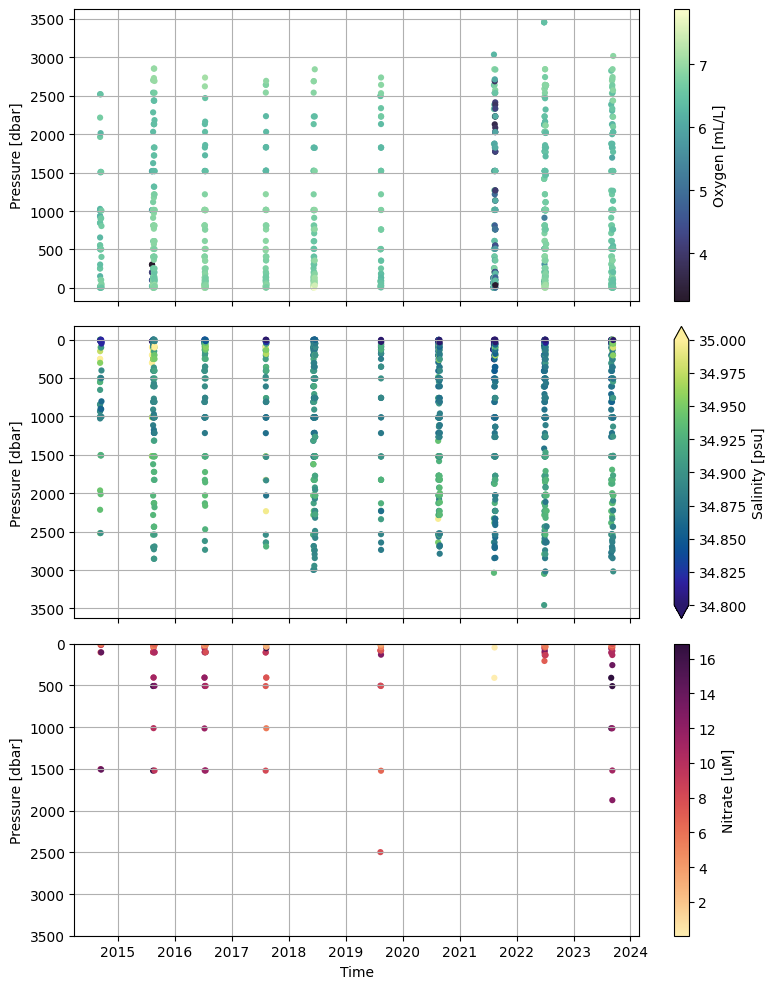

In [14]:

# Create the subplots with time on the x-axis
fig, axs = plt.subplots(3, 1, figsize=(8,10), sharex=True, layout="tight")

# Discrete Oxygen
plt.subplot(3,1,1)
#axs[0].invert_yaxis()
plt.scatter(x=discrete_time[flag_oxy], y=irm_qc["CTD_Pressure"][flag_oxy], s=20,
            c=irm_qc["Discrete_Oxygen"][flag_oxy], cmap=cmap_oxy,
            edgecolors="none")
plt.grid()
plt.colorbar(label="Oxygen [mL/L]")
axs[0].set_ylabel("Pressure [dbar]")

# Discrete Salinity
plt.subplot(3,1,2)
axs[1].invert_yaxis()
plt.scatter(x=discrete_time[flag_sal], y=irm_qc["CTD_Pressure"][flag_sal], s=20,
            c=irm_qc["Discrete_Salinity"][flag_sal], cmap=cmap_salt,
            edgecolors="none", vmin=34.8, vmax=35)

plt.grid()
plt.colorbar(label="Salinity [psu]", extend='both')
axs[1].set_ylabel("Pressure [dbar]")

# Discrete Nitrate
plt.subplot(3,1,3)
axs[2].set_ylim([0, 3500])
axs[2].invert_yaxis()
plt.scatter(x=discrete_time[flag_ntr], y=irm_qc["CTD_Pressure"][flag_ntr], s=20,
            c=irm_qc["Discrete_Nitrate"][flag_ntr], cmap=cmap_nitr,
            edgecolors="none")
plt.grid()
plt.colorbar(label="Nitrate [uM]")
axs[2].set_ylabel("Pressure [dbar]")

axs[2].set_xlabel("Time")

**Figure 2.** Plot oxygen, salinity, and nitrate concentrations as a function of depth

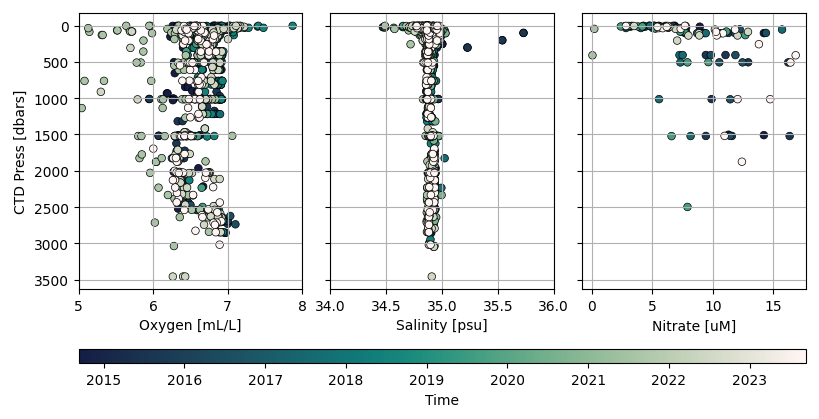

In [15]:
# Create the subplots with time indicated by color
fig, axs = plt.subplots(1, 3, figsize=(8,4), sharey=True, constrained_layout=True)
subfig = fig.subfigures(nrows=1, ncols=1)

# Discrete Oxygen
plt.subplot(1,3,1)
axs[0].invert_yaxis()
plt.scatter(x=irm_qc["Discrete_Oxygen"][flag_oxy], y=irm_qc["CTD_Pressure"][flag_oxy], s=30,
            c=discrete_mpl_time[flag_oxy], cmap=cmap_time, norm=normalizer,
            edgecolors="k", linewidths=0.5)
plt.grid()
axs[0].set_ylabel("CTD Press [dbars]")
axs[0].set_xlabel("Oxygen [mL/L]")
axs[0].set_xlim([5,8])

# Discrete Salinity
plt.subplot(1,3,2)
axs[1].invert_yaxis()
plt.scatter(x=irm_qc["Discrete_Salinity"][flag_sal], y=irm_qc["CTD_Pressure"][flag_sal],
            c=discrete_mpl_time[flag_sal], cmap=cmap_time, s=30, norm=normalizer,
            edgecolors="k", linewidths=0.5)
plt.grid()
axs[1].set_xlabel("Salinity [psu]")
axs[1].set_xlim([34,36])

# Discrete Nitrate
plt.subplot(1,3,3)
axs[2].invert_yaxis()
plt.scatter(x=irm_qc["Discrete_Nitrate"][flag_ntr], y=irm_qc["CTD_Pressure"][flag_ntr], s=30,
            c=discrete_mpl_time[flag_ntr], cmap=cmap_time, norm=normalizer,
            edgecolors="k", linewidths=0.5)
plt.grid()
axs[2].set_xlabel("Nitrate [uM]")

time_map = cm.ScalarMappable(norm=normalizer, cmap=cmap_time)
subfig.colorbar(time_map, ax=axs.ravel().tolist(), label="Time", ticks=AutoDateLocator(),
             format=AutoDateFormatter(locator), location="bottom", aspect=50)
plt.show()

## Plot just subset data

In [16]:
# set up time for matplotlib plots (subset of data)
discrete_time_subset = ooi_subset["CTD_Bottle_Closure_Time"].values

# Create a matplotlib-friendly numeric time array
discrete_mpl_time_subset = mpl.dates.date2num(discrete_time_subset)

# Create normalizer for colorbar representing the full date range
normalizer_subset = Normalize(discrete_mpl_time_subset[0], discrete_mpl_time_subset[-1])

# Create tick locator for using time as the color scale
locator_subset = AutoDateLocator()



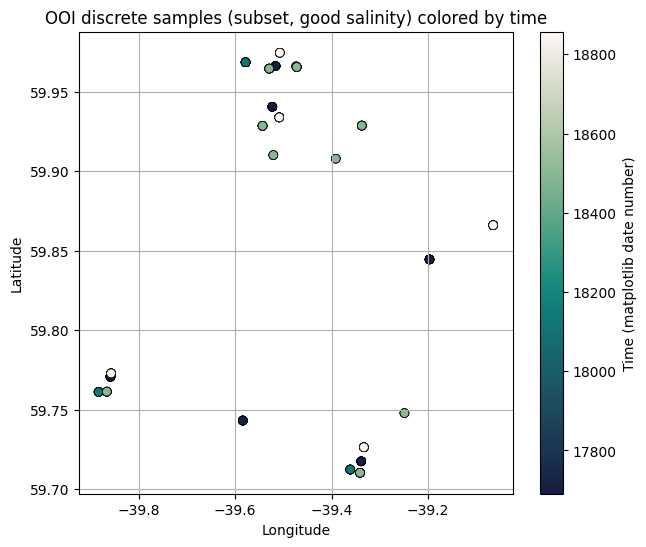

In [17]:
from matplotlib.dates import date2num
# Plot the subset locations, colored by time (good salinity only)
ooi_time = ooi_subset.loc[ooi_flag_sal, "CTD_Bottle_Closure_Time"].values
ooi_tnum = date2num(ooi_time)

norm = Normalize(ooi_tnum.min(), ooi_tnum.max())

fig, ax = plt.subplots(figsize=(7, 6))

sc = ax.scatter(
    x=ooi_subset.loc[ooi_flag_sal, "Start_Longitude"],
    y=ooi_subset.loc[ooi_flag_sal, "Start_Latitude"],
    c=ooi_tnum,
    cmap=cmap_time,
    norm=norm,
    s=40,
    edgecolors="k",
    linewidths=0.5
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("OOI discrete samples (subset, good salinity) colored by time")
ax.grid(True)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Time (matplotlib date number)")

plt.show()

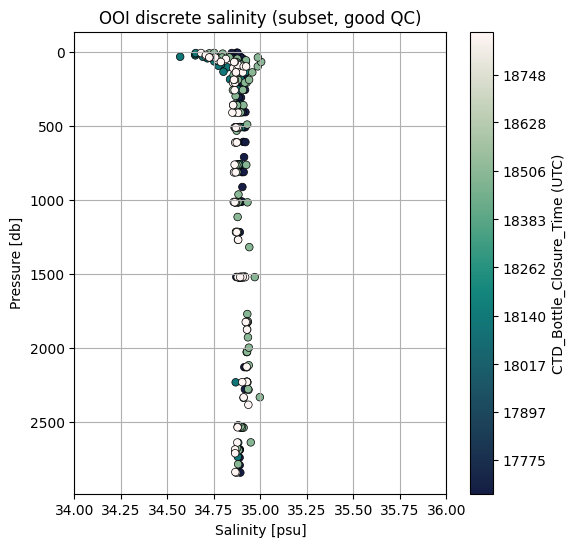

In [18]:
## Plot the subsets
# Ensure we are using the subset and subset QC mask
# flag_sal must have been computed from irm_subset:
# flag_sal = irm_subset["Discrete_Salinity_Flag"] == 1
# Build time color values from the SUBSET (and only the good salinity rows)
ooi_time_subset = ooi_subset.loc[ooi_flag_sal, "CTD_Bottle_Closure_Time"].values
ooi_mpl_time_subset = mpl.dates.date2num(ooi_time_subset)

# Normalizer should be based on the subset range (min/max), not first/last row
normalizer_subset = Normalize(ooi_mpl_time_subset.min(), ooi_mpl_time_subset.max())

fig, ax = plt.subplots(figsize=(6, 6))
ax.invert_yaxis()

sc = ax.scatter(
    x=ooi_subset.loc[ooi_flag_sal, "Discrete_Salinity"],
    y=ooi_subset.loc[ooi_flag_sal, "CTD_Pressure"],
    c=ooi_mpl_time_subset,
    cmap=cmap_time,
    s=30,
    norm=normalizer_subset,
    edgecolors="k",
    linewidths=0.5
)

ax.grid(True)
ax.set_xlabel("Salinity [psu]")
ax.set_ylabel("Pressure [db]")
ax.set_title("OOI discrete salinity (subset, good QC)")

# Optional x-limits (keep if appropriate for your region/time window)
ax.set_xlim([34, 36])

# Colorbar using same pattern as earlier plots
cbar = fig.colorbar(sc, ax=ax)
locator_subset = AutoDateLocator()
cbar.ax.yaxis.set_major_locator(locator_subset)
cbar.set_label("CTD_Bottle_Closure_Time (UTC)")

plt.show()

## Dataset 1: Record your data citation

Record a data citation for the source data you used.  You can get the template for citing the data (or subset) used by clicking the "Cite Dataset" button (top right).

Data Citation:
> NSF Ocean Observatories Initiative (2025). OOI Global Irminger Sea Array CTD and Discrete Water Sampling Data from Mooring Overturning Cruises in the Irminger Sea from 2014-2023 (OOI Cruise Data project). Biological and Chemical Oceanography Data Management Office (BCO-DMO). (Version 1) Version Date 2023-10-24 **[if applicable, indicate subset used]**. doi:10.26008/1912/bco-dmo.911407.1 **[access date]**

(ERDDAP if subsetting used you can copy the provided query link by pressing “generate URL” for the exact data you downloaded)

Note: DOIs at BCO-DMO are for the archival copy of a particular data version. So that's best to use when citing the data (e.g. doi:[10.26008/1912/bco-dmo.911407.1](https://doi.org/10.26008/1912/bco-dmo.911407.1)).

Note: A BCO-DMO Dataset Landing Page will always show the most recent version and have enhanced views of the metadata and data access features compared to the archival page (10.26008/1912/bco-dmo.911407.1) or ERDDAP (https://erddap.bco-dmo.org/erddap/info/bcodmo_dataset_911407_v1/index.html).

# DATASET 2 - ARGO profiles

## Dataset 2: Find data source

Find Argo profiles near the OOI Irminger Sea Hybrid Profiler Mooring [GI02HYPM](https://oceanobservatories.org/site/gi02hypm/).  

We will eventually want to limit to Target bounding box: 59.5 to 60.5 N, 40 to 39 W and time (2018-2021) as well but let's just find the data first.

**A few helpful argopy References**
* [Fetching ARGO Data](https://argopy.readthedocs.io/en/latest/user-guide/fetching-argo-data/index.html)
* [ARGO Index Store](https://argopy.readthedocs.io/en/latest/advanced-tools/stores/argoindex.html)
* [Aargopy Cheat Sheet](https://argopy.readthedocs.io/en/latest/cheatsheet.html)
* [Working with ARGO Index](https://github.com/euroargodev/argopy-training/blob/main/content/argo-index-meta-data/working-with-argo-index.ipynb)

## Dataset 2: Inspect data/metadata for context

https://erddap.ifremer.fr/erddap/info/ArgoFloats/index.html

https://erddap.ifremer.fr/erddap/tabledap/ArgoFloats.html

References documenation here http://www.argodatamgt.org/Documentation

## Dataset 2: Access data


In [19]:
from argopy import DataFetcher

# Setup DataFetcher to query data for a given space/time region
f = DataFetcher().region([-40, -39, 59.5, 60.5, 0, 1000, '2018-01-01', '2021-12-31'])

(<Figure size 900x540 with 1 Axes>,
 <Axes: xlabel='longitude', ylabel='latitude'>)

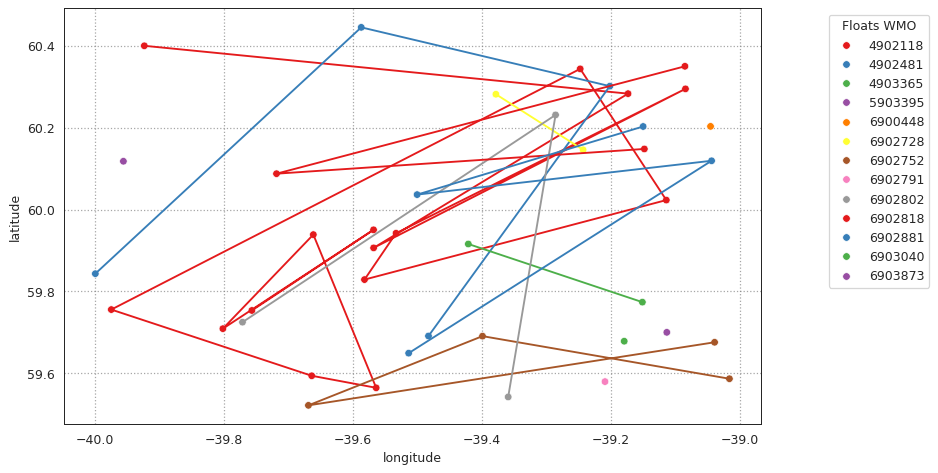

In [20]:
# The DataFetcher method has a quick method to plot profile trajectories
f.plot('trajectory')

The DataFetcher method does not load the data, it just creates an index.  There are a number of ways we can load either the full dataset or just the index into memory, but depending on how much data you have, it could take quite a while.

Note that `DataFetcher.to_xarray()` and `DataFetcher.to_index()` will force data download on every call, while the `DataFetcher.load()` method will keep data in memory in the `DataFetcher.data` and `DataFetcher.index` properties.  [reference](https://argopy.readthedocs.io/en/latest/user-guide/fetching-argo-data/index.html)


## Dataset 2: Inspect data/metadata

In [21]:
%%time
# Load the data into an xarray Dataset.  This can take a long time if you request a lot of data.
ds_data = f.data
ds_data

CPU times: user 1.39 ms, sys: 37 µs, total: 1.43 ms
Wall time: 2.59 ms


<xarray.Dataset> Size: 2MB
Dimensions:          (N_POINTS: 18685)
Coordinates:
    LATITUDE         (N_POINTS) float64 149kB 60.2 60.2 60.2 ... 59.84 59.84
    LONGITUDE        (N_POINTS) float64 149kB -39.05 -39.05 ... -40.0 -40.0
    TIME             (N_POINTS) datetime64[ns] 149kB 2018-05-30T21:10:55 ... ...
  * N_POINTS         (N_POINTS) int64 149kB 0 1 2 3 ... 18681 18682 18683 18684
Data variables: (12/15)
    CYCLE_NUMBER     (N_POINTS) int64 149kB 257 257 257 257 257 ... 82 82 82 82
    DATA_MODE        (N_POINTS) <U1 75kB 'D' 'D' 'D' 'D' 'D' ... 'R' 'R' 'R' 'R'
    DIRECTION        (N_POINTS) <U1 75kB 'A' 'A' 'A' 'A' 'A' ... 'A' 'A' 'A' 'A'
    PLATFORM_NUMBER  (N_POINTS) int64 149kB 6900448 6900448 ... 4902481 4902481
    POSITION_QC      (N_POINTS) int64 149kB 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    PRES             (N_POINTS) float32 75kB 24.9 30.5 35.7 ... 993.3 998.0
    ...               ...
    PSAL_ERROR       (N_POINTS) float32 75kB 0.01 0.01 0.01 0.01 ... nan nan nan
    PSAL_QC          (N_POINTS) int64 149kB 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    TEMP             (N_POINTS) float32 75kB 4.57 4.546 4.538 ... 3.425 3.424
    TEMP_ERROR       (N_POINTS) float32 75kB 0.002 0.002 0.002 ... nan nan nan
    TEMP_QC          (N_POINTS) int64 149kB 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    TIME_QC          (N_POINTS) int64 149kB 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
Attributes:
    DATA_ID:              ARGO
    DOI:                  http://doi.org/10.17882/42182
    Fetched_from:         erddap.ifremer.fr
    Fetched_by:           root
    Fetched_date:         2026/03/10
    Fetched_constraints:  [x=-40.00/-39.00; y=59.50/60.50; z=0.0/1000.0; t=20...
    Fetched_uri:          https://erddap.ifremer.fr/erddap/tabledap/ArgoFloat...
    Processing_history:   [PRES,TEMP,PSAL] real-time and adjusted/delayed var...

In [22]:
%%time
# We can also load just the index into a pandas DataFrame, which is much faster.
df_index = f.index
df_index.head()

CPU times: user 2.82 ms, sys: 78 µs, total: 2.9 ms
Wall time: 10.8 ms


,date,latitude,longitude,wmo,cyc
0,2018-08-27 03:10:09,60.39997,-39.92354,4902118,82
1,2018-10-15 19:30:07,60.28311,-39.17325,4902118,87
2,2018-10-25 18:04:08,59.90653,-39.56790,4902118,88
3,2018-11-24 13:43:47,60.29484,-39.08417,4902118,91
4,2018-12-04 12:11:38,59.94224,-39.53314,4902118,92


In [23]:
# And can convert the 1D point data to a data frame
df_argo = ds_data.to_dataframe()
df_argo = df_argo.reset_index()
df_argo

,N_POINTS,CYCLE_NUMBER,DATA_MODE,DIRECTION,PLATFORM_NUMBER,POSITION_QC,PRES,PRES_ERROR,PRES_QC,PSAL,PSAL_ERROR,PSAL_QC,TEMP,TEMP_ERROR,TEMP_QC,TIME_QC,LATITUDE,LONGITUDE,TIME
0,0,257,D,A,6900448,1,24.900000,2.4,1,34.889999,0.01,1,4.570,0.002,1,1,60.203200,-39.045300,2018-05-30 21:10:55
1,1,257,D,A,6900448,1,30.500000,2.4,1,34.890999,0.01,1,4.546,0.002,1,1,60.203200,-39.045300,2018-05-30 21:10:55
2,2,257,D,A,6900448,1,35.700001,2.4,1,34.889999,0.01,1,4.538,0.002,1,1,60.203200,-39.045300,2018-05-30 21:10:55
3,3,257,D,A,6900448,1,40.500000,2.4,1,34.890999,0.01,1,4.531,0.002,1,1,60.203200,-39.045300,2018-05-30 21:10:55
4,4,257,D,A,6900448,1,50.200001,2.4,1,34.890999,0.01,1,4.524,0.002,1,1,60.203200,-39.045300,2018-05-30 21:10:55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18680,18680,82,R,A,4902481,1,977.599976,NaN,1,34.865002,NaN,1,3.434,NaN,1,1,59.843525,-39.999542,2021-09-03 02:24:00
18681,18681,82,R,A,4902481,1,983.000000,NaN,1,34.863998,NaN,1,3.432,NaN,1,1,59.843525,-39.999542,2021-09-03 02:24:00
18682,18682,82,R,A,4902481,1,988.299988,NaN,1,34.863998,NaN,1,3.428,NaN,1,1,59.843525,-39.999542,2021-09-03 02:24:00
18683,18683,82,R,A,4902481,1,993.299988,NaN,1,34.863998,NaN,1,3.425,NaN,1,1,59.843525,-39.999542,2021-09-03 02:24:00


In [24]:
# Save full Argo dataframe (just in case)
#df_argo.to_csv("argo_subset_points.csv", index=False)

In [26]:
# disaster recovery option
#df_argo = pd.read_csv("argo_subset_points.csv")
#df_argo



##  Dataset 2: Transform data (if needed)

By default, the dataset is returned as a 1D point dataset.  We can also convert it to a 2D array of vertical profiles.

In [27]:
# Convert points to profiles
ds_profiles = ds_data.argo.point2profile()
ds_profiles

<xarray.Dataset> Size: 589kB
Dimensions:          (N_PROF: 42, N_LEVELS: 690)
Coordinates:
  * N_PROF           (N_PROF) int64 336B 22 21 0 1 2 3 4 ... 16 29 19 17 20 18
  * N_LEVELS         (N_LEVELS) int64 6kB 0 1 2 3 4 5 ... 685 686 687 688 689
    LATITUDE         (N_PROF) float64 336B 60.2 60.12 60.4 ... 60.44 59.77 59.84
    LONGITUDE        (N_PROF) float64 336B -39.05 -39.96 -39.92 ... -39.15 -40.0
    TIME             (N_PROF) datetime64[ns] 336B 2018-05-30T21:10:55 ... 202...
Data variables: (12/15)
    CYCLE_NUMBER     (N_PROF) int64 336B 257 267 82 87 88 91 ... 101 1 80 2 82
    DATA_MODE        (N_PROF) <U1 168B 'D' 'D' 'D' 'D' 'D' ... 'D' 'R' 'D' 'R'
    DIRECTION        (N_PROF) <U1 168B 'A' 'A' 'A' 'A' 'A' ... 'A' 'A' 'A' 'A'
    PLATFORM_NUMBER  (N_PROF) int64 336B 6900448 5903395 ... 4903365 4902481
    POSITION_QC      (N_PROF) int64 336B 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1
    PRES             (N_PROF, N_LEVELS) float32 116kB 24.9 30.5 35.7 ... nan nan
    ...               ...
    PSAL_ERROR       (N_PROF, N_LEVELS) float32 116kB 0.01 0.01 0.01 ... nan nan
    PSAL_QC          (N_PROF) int64 336B 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1
    TEMP             (N_PROF, N_LEVELS) float32 116kB 4.57 4.546 ... nan nan
    TEMP_ERROR       (N_PROF) float32 168B 0.002 0.002 0.002 ... nan 0.002 nan
    TEMP_QC          (N_PROF) int64 336B 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1
    TIME_QC          (N_PROF) int64 336B 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1
Attributes:
    DATA_ID:              ARGO
    DOI:                  http://doi.org/10.17882/42182
    Fetched_from:         erddap.ifremer.fr
    Fetched_by:           root
    Fetched_date:         2026/03/10
    Fetched_constraints:  [x=-40.00/-39.00; y=59.50/60.50; z=0.0/1000.0; t=20...
    Fetched_uri:          https://erddap.ifremer.fr/erddap/tabledap/ArgoFloat...
    Processing_history:   [PRES,TEMP,PSAL] real-time and adjusted/delayed var...

Now that we have the data loaded, argopy provides a nice set of methods to interpolate data to common pressure levels or to group the data in pressure bins [see here](https://argopy.readthedocs.io/en/latest/user-guide/working-with-argo-data/data_manipulation.html).  It also has menthods for calculating [optional variables](https://argopy.readthedocs.io/en/latest/user-guide/working-with-argo-data/data_computation.html).  But we'll skip that for now.

### Apply QA Flags

Since we are concentrating on salinity, let's make sure we know how to use just the data values where the QC flag for that is 1

## Dataset 2: Visualize Data

In [28]:
import matplotlib.pyplot as plt

year
2018     9
2019    11
2020     9
2021    13
Name: count, dtype: int64


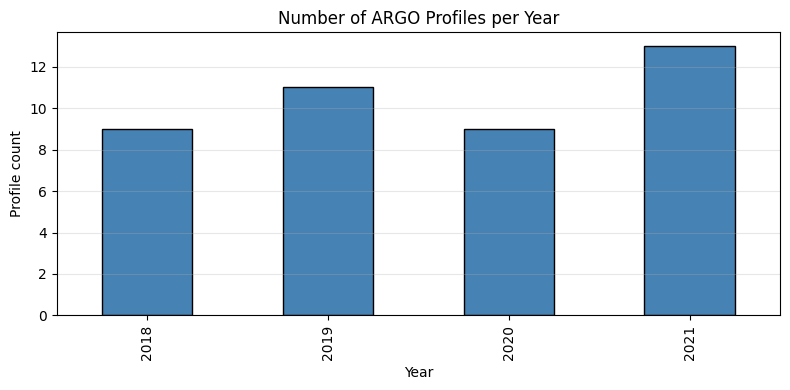

In [29]:
# Count profiles per year
profiles_per_year = (
    ds_profiles["TIME"]
    .dt.year
    .to_series()
    .value_counts()
    .sort_index()
)

print(profiles_per_year)

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
profiles_per_year.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Number of ARGO Profiles per Year")
ax.set_xlabel("Year")
ax.set_ylabel("Profile count")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

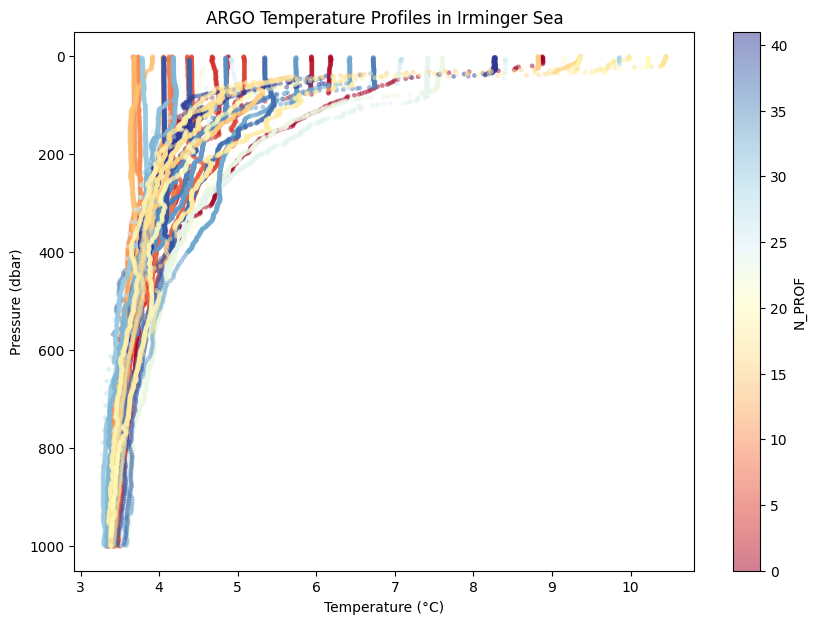

In [30]:
fig, ax = plt.subplots(figsize=(10, 7))
ds_profiles.plot.scatter(x='TEMP', y='PRES', hue='N_PROF',
    ax=ax, yincrease=False, cmap='RdYlBu',
    marker='o', s=12, alpha=.5, edgecolors='none', linewidths=0.25,
)
ax.set_title('ARGO Temperature Profiles in Irminger Sea')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Pressure (dbar)')
plt.show()

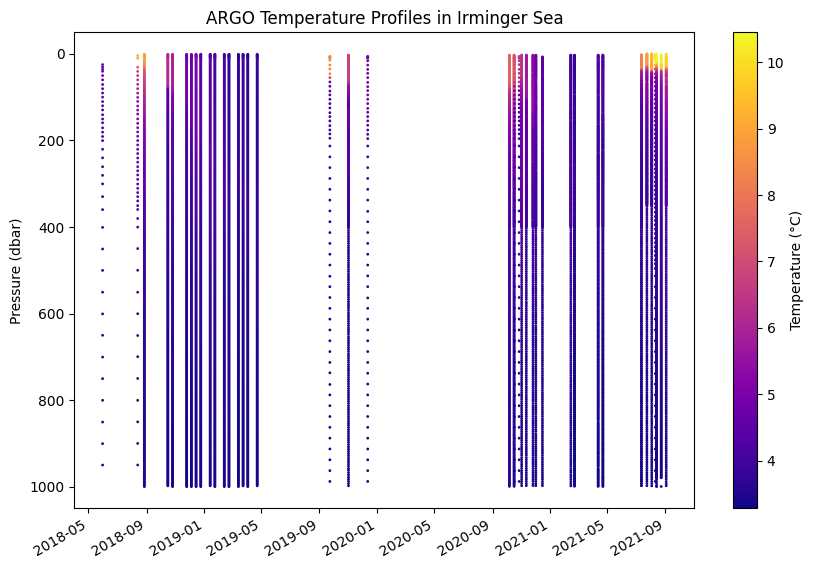

In [31]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(x=ds_data['TIME'], y=ds_data['PRES'], c=ds_data['TEMP'], s=1, cmap='plasma')
fig.colorbar(sc, ax=ax, label='Temperature (°C)')

ax.set_title('ARGO Temperature Profiles in Irminger Sea')
ax.set_ylabel('Pressure (dbar)')
ax.invert_yaxis()
fig.autofmt_xdate()
plt.show()

### ARGO Index
The method above, which loads the profile data directly can take a long time.  If you know you have a lot of profiles, it might be useful to query the Argo Index first to find those you are most interested in.

##### Examples

```
# index of all records

from argopy import ArgoIndex
idx = ArgoIndex()
idx.load()
idx.N_RECORDS
```
 gives 3305669

---

```
# Index just in space and time of interest (Irminger Sea Area 2018-2021)
# box = [-42, -37, 58, 61, '2018-01-01', '2021-12-31']
box = [-40, -39, 59.5, 60.5, '2018-01-01', '2021-12-31']
idx.query.box(box)
idx.N_MATCH
```

 gives 53

# Look at the datasets together

For our usecase we want to know if we can use the salinity from both datsets together. Let's look at the documentation again and pull out what the salinity, pressure, lat, lon, and time reported in both datasets.  See if the type of measurment and units are compatible to use together.


In [44]:
#### OOI Discrete Sampling
# ARGO dataset has this salinity
#  .attrs to get the information about it since it is an xarray.Dataset
ds_data["PSAL"].attrs

{'long_name': 'PRACTICAL SALINITY',
 'standard_name': 'sea_water_salinity',
 'units': 'psu',
 'valid_min': 0.0,
 'valid_max': 43.0,
 'resolution': 0.001,
 'casted': 1}


| Variable Name | long_name                                              | units                                  |
|---------------|--------------------------------------------------------|----------------------------------------|
| latitude      | Latitude of the station, best estimate                 | degrees_north                         |
| longitude     | Longitude of the station, best estimate                | degrees_east                          |
| pres          | Sea water pressure, equals 0 at sea-level              | decibar                               |
| psal          | Practical salinity                                     | PSU                                   |
| time          | Julian day (UTC) of the station relative to RE...      | seconds since 1970-01-01T00:00:00Z     |

OOI discrete dataset

 we loaded as a data frame that just has values so we have to look at the metadata

ooi_irm["Discrete_Salinity"] came from a BCO-DMO dataset so we can look at the dataset landing page or the ERDDAP metadata page

https://www.bco-dmo.org/dataset/911407 ("See Parameters")

| supplied_name             | supplied_units   | description                                                       | parameter_official_name | parameter_description                                                  |
|----------------------------|------------------|-------------------------------------------------------------------|--------------------------|------------------------------------------------------------------------|
| Start_Latitude             | decimal degrees  | Latitude derived from the elog reading at the start of sampling. | lat_start                | latitude at start time of measurement; in decimal degrees             |
| Start_Longitude            | decimal degrees  | Longitude derived from the elog reading at the start of sampling.| lon_start                | longitude at starting time of measurement (west negative)             |
| CTD_Bottle_Closure_Time    | unitless         | Datetime of Niskin bottle closure.                                | time_end                 | ending time of observation, GMT time, 24 hour format                  |
| CTD_Pressure               | db               | Pressure measurement from CTD digiquartz pressure sensor.         | pressure                 | water pressure at measurement; depth reported in decibar              |
| Discrete_Salinity          | psu              | Discrete salinity taken from water sample.                        | sal_bottle               | bottle salinity, Practical Salinity Scale, dimensionless              |

# Explore how co-located the datasets are (discrete vs continuous profiles)

Before plotting both datasets together, it helps to quantify how well they overlap in:

- **Time** (nearest Argo profile time to each OOI discrete profile)
- **Location** (great-circle distance between profile locations)
- **Pressure range** (how much vertical overlap exists)

## Build `df_discrete` (OOI sampling) and `df_continuous` (Argo floats)

This cell standardizes both datasets into pandas DataFrames for the form of the data we want to move forward with:

- `profile_id`
- `time`
- `lat`, `lon`
- `pressure`
- `salinity`

You can go on to plot and use the data as they are in the original arrays but after this we will be referencing the same kind of measurements with the same name in the data frames between the two datasets.

For example, we will be able to compare the OOI data with `df_discrete['sal']` and Argo with `df_continuous['sal']`
instead of having to get those values for the data we decided to use like:
`irm_qc["CTD_Bottle_Closure_Time"].values[flag_sal]` (values just at the "good" salinity locations)

In [34]:
# --- Discrete profiles: OOI sampling (from "ooi_irm" loaded earlier) ---
# populate these with the OOI QC'ed data where we have the salinity flags as 1

# Initialize empty dataframes
df_discrete = pd.DataFrame()
df_continuous = pd.DataFrame()

# OOI (discrete sampling profile)
#we previously used the index for the locations where the flag is 1 as "flag_sal"
df_discrete = pd.DataFrame({
    "time": pd.to_datetime(ooi_subset["CTD_Bottle_Closure_Time"].values[ooi_flag_sal]),
    "sal": ooi_subset["Discrete_Salinity"].values[ooi_flag_sal],
    "lat": ooi_subset["Start_Latitude"].values[ooi_flag_sal],
    "lon": ooi_subset["Start_Longitude"].values[ooi_flag_sal],
    "pressure": ooi_subset["CTD_Pressure"].values[ooi_flag_sal],
})

df_discrete.head()


,time,sal,lat,lon,pressure
0,2018-06-08 19:28:31,34.8928,59.9405,-39.523,1520.775
1,2018-06-08 19:39:11,34.8808,59.9405,-39.523,1013.805
2,2018-06-08 19:52:04,34.9120,59.9405,-39.523,507.319
3,2018-06-08 20:01:03,34.9174,59.9405,-39.523,254.488
4,2018-06-08 20:08:25,34.8788,59.9405,-39.523,131.784


In [35]:
# --- Continuous profiles: Argo floats ---

# Boolean mask for good practical salinity
argo_good_sal_flag = df_argo["PSAL_QC"] == 1

# Build standardized dataframe using the flag index
df_continuous = pd.DataFrame({
    "time": pd.to_datetime(df_argo.loc[argo_good_sal_flag, "TIME"], utc=True, errors="coerce"),
    "sal": df_argo.loc[argo_good_sal_flag, "PSAL"],
    "lat": df_argo.loc[argo_good_sal_flag, "LATITUDE"],
    "lon": df_argo.loc[argo_good_sal_flag, "LONGITUDE"],
    "pressure": df_argo.loc[argo_good_sal_flag, "PRES"],
})

df_continuous = (
    df_continuous
    .dropna(subset=["time", "sal", "pressure", "lat", "lon"])
    .reset_index(drop=True)
)

df_continuous.head()

,time,sal,lat,lon,pressure
0,2018-05-30 21:10:55+00:00,34.889999,60.2032,-39.0453,24.900000
1,2018-05-30 21:10:55+00:00,34.890999,60.2032,-39.0453,30.500000
2,2018-05-30 21:10:55+00:00,34.889999,60.2032,-39.0453,35.700001
3,2018-05-30 21:10:55+00:00,34.890999,60.2032,-39.0453,40.500000
4,2018-05-30 21:10:55+00:00,34.890999,60.2032,-39.0453,50.200001


## Profile-level co-location metrics (time, distance, pressure overlap)

We reduce each dataset to one row per profile with:
- median time
- median lat/lon (if present)
- min/max pressure

Then we match each discrete profile to the nearest continuous profile in time and compute:
- `dt_hours`
- `distance_km` (if both have lat/lon)
- `p_common_span` (overlapping pressure range)


In [45]:
# Ensure datetime
df_discrete["time"] = pd.to_datetime(df_discrete["time"], utc=True, errors="coerce")
df_continuous["time"] = pd.to_datetime(df_continuous["time"], utc=True, errors="coerce")

In [46]:
# Create profile id as time

if "profile_id" not in df_discrete.columns:
    df_discrete = df_discrete.copy()
    df_discrete["profile_id"] = df_discrete["time"].dt.floor("1D").astype(str)

if "profile_id" not in df_continuous.columns:
    df_continuous = df_continuous.copy()
    if {"platform_number", "cycle_number"}.issubset(df_continuous.columns):
        df_continuous["profile_id"] = (
            df_continuous["platform_number"].astype(str).str.strip() + "_"
            + df_continuous["cycle_number"].astype(str)
        )
    else:
        df_continuous["profile_id"] = df_continuous["time"].dt.floor("1D").astype(str)

df_discrete[["profile_id", "time"]].head(), df_continuous[["profile_id", "time"]].head()

(                  profile_id                      time
 0  2018-06-08 00:00:00+00:00 2018-06-08 19:28:31+00:00
 1  2018-06-08 00:00:00+00:00 2018-06-08 19:39:11+00:00
 2  2018-06-08 00:00:00+00:00 2018-06-08 19:52:04+00:00
 3  2018-06-08 00:00:00+00:00 2018-06-08 20:01:03+00:00
 4  2018-06-08 00:00:00+00:00 2018-06-08 20:08:25+00:00,
                   profile_id                      time
 0  2018-05-30 00:00:00+00:00 2018-05-30 21:10:55+00:00
 1  2018-05-30 00:00:00+00:00 2018-05-30 21:10:55+00:00
 2  2018-05-30 00:00:00+00:00 2018-05-30 21:10:55+00:00
 3  2018-05-30 00:00:00+00:00 2018-05-30 21:10:55+00:00
 4  2018-05-30 00:00:00+00:00 2018-05-30 21:10:55+00:00)

In [47]:
def profile_table(df):
    # one row per profile_id
    out = (df.groupby("profile_id")
             .agg(
                 time_med=("time", "median"),
                 lat_med=("lat", "median") if "lat" in df.columns else ("time", lambda s: np.nan),
                 lon_med=("lon", "median") if "lon" in df.columns else ("time", lambda s: np.nan),
                 p_min=("pressure", "min"),
                 p_max=("pressure", "max"),
                 n=("pressure", "count")
             )
             .reset_index()
             .sort_values("time_med")
          )
    return out

disc_prof = profile_table(df_discrete)
cont_prof = profile_table(df_continuous)

disc_prof.head(), cont_prof.head()

(                  profile_id                  time_med    lat_med    lon_med  \
 0  2018-06-08 00:00:00+00:00 2018-06-08 20:10:53+00:00  59.940500 -39.523000   
 1  2018-06-09 00:00:00+00:00 2018-06-09 15:27:03+00:00  59.966167 -39.516333   
 2  2018-06-10 00:00:00+00:00 2018-06-10 16:28:38+00:00  59.770667 -39.859000   
 3  2018-06-12 00:00:00+00:00 2018-06-12 21:03:34+00:00  59.844500 -39.196833   
 4  2018-06-15 00:00:00+00:00 2018-06-15 17:47:25+00:00  59.743167 -39.584167   
 
      p_min     p_max   n  
 0    3.017  1520.775  11  
 1  151.844  2688.276  13  
 2   30.496  2690.634  13  
 3    3.129  1010.214  12  
 4    5.078  2794.205  13  ,
                   profile_id                  time_med   lat_med   lon_med  \
 0  2018-05-30 00:00:00+00:00 2018-05-30 21:10:55+00:00  60.20320 -39.04530   
 1  2018-08-13 00:00:00+00:00 2018-08-13 01:53:28+00:00  60.11800 -39.95600   
 2  2018-08-27 00:00:00+00:00 2018-08-27 03:10:09+00:00  60.39997 -39.92354   
 3  2018-10-15 00:00:00+00:

In [ ]:
### TODO analyze and report distance in space/time

# Visualize both datasets` salinity together using pressure (dbar)


In [39]:
## TODO (plot both in lat/lon space with dots over trajectories)

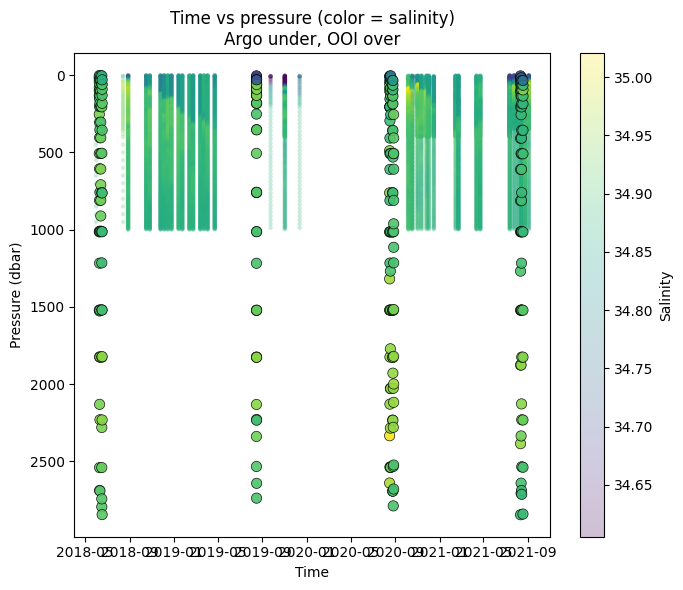

In [48]:
#  Time vs. Pressure (colored salinity)

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import Normalize
import numpy as np
import pandas as pd

# Ensure datetime
df_discrete["time"] = pd.to_datetime(df_discrete["time"], utc=True, errors="coerce")
df_continuous["time"] = pd.to_datetime(df_continuous["time"], utc=True, errors="coerce")

# Drop missing
d = df_discrete.dropna(subset=["time", "pressure", "sal"]).copy()
c = df_continuous.dropna(subset=["time", "pressure", "sal"]).copy()

plt.figure(figsize=(7, 6))

# Argo underneath
sc = plt.scatter(
    c["time"], c["pressure"],
    c=c["sal"], s=10, alpha=0.25,
    edgecolors="none"
)

# OOI on top
plt.scatter(
    d["time"], d["pressure"],
    c=d["sal"], s=55, alpha=0.9,
    edgecolors="k", linewidths=0.5
)

plt.gca().invert_yaxis()
plt.title("Time vs pressure (color = salinity)\nArgo under, OOI over")
plt.xlabel("Time")
plt.ylabel("Pressure (dbar)")

cbar = plt.colorbar(sc)
cbar.set_label("Salinity")

plt.tight_layout()
plt.show()

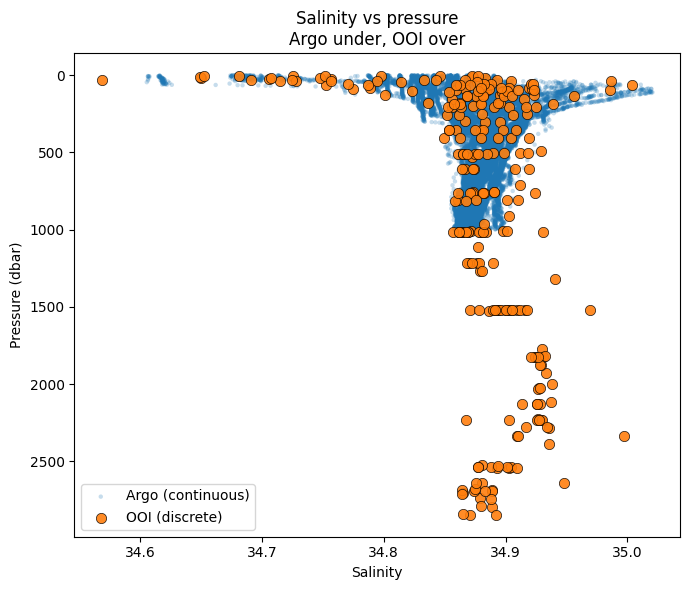

In [49]:
# Salinity vs. pressure

plt.figure(figsize=(7, 6))

# Argo underneath
plt.scatter(
    c["sal"], c["pressure"],
    s=10, alpha=0.25,
    edgecolors="none",
    label="Argo (continuous)"
)

# OOI on top
plt.scatter(
    d["sal"], d["pressure"],
    s=55, alpha=0.9,
    edgecolors="k", linewidths=0.5,
    label="OOI (discrete)"
)

plt.gca().invert_yaxis()
plt.title("Salinity vs pressure\nArgo under, OOI over")
plt.xlabel("Salinity")
plt.ylabel("Pressure (dbar)")
plt.legend()

plt.tight_layout()
plt.show()

## Same plots with plotly

In [50]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# Ensure datetime
df_discrete["time"] = pd.to_datetime(df_discrete["time"], utc=True, errors="coerce")
df_continuous["time"] = pd.to_datetime(df_continuous["time"], utc=True, errors="coerce")

# Drop missing
d = df_discrete.dropna(subset=["time", "pressure", "sal"]).copy()
c = df_continuous.dropna(subset=["time", "pressure", "sal"]).copy()

# Shared salinity range
sal_min = np.nanmin(np.r_[d["sal"].values, c["sal"].values])
sal_max = np.nanmax(np.r_[d["sal"].values, c["sal"].values])

fig = go.Figure()

# --- Argo underneath ---
fig.add_trace(go.Scatter(
    x=c["time"],
    y=c["pressure"],
    mode="markers",
    marker=dict(
        size=4,
        color=c["sal"],
        colorscale="Viridis",
        cmin=sal_min,
        cmax=sal_max,
        opacity=0.3,
        showscale=True,
        colorbar=dict(title="Salinity")
    ),
    name="Argo (continuous)",
    hovertemplate="Time: %{x}<br>Pressure: %{y:.1f} dbar<br>Salinity: %{marker.color:.4f}<extra></extra>"
))

# --- OOI on top ---
fig.add_trace(go.Scatter(
    x=d["time"],
    y=d["pressure"],
    mode="markers",
    marker=dict(
        size=9,
        color=d["sal"],
        colorscale="Viridis",
        cmin=sal_min,
        cmax=sal_max,
        line=dict(color="black", width=0.8),
        opacity=0.95,
        showscale=False
    ),
    name="OOI (discrete)",
    hovertemplate="Time: %{x}<br>Pressure: %{y:.1f} dbar<br>Salinity: %{marker.color:.4f}<extra></extra>"
))

fig.update_layout(
    title="Time vs pressure (color = salinity)<br>Argo under, OOI over",
    xaxis_title="Time",
    yaxis_title="Pressure (dbar)",
    legend_title="Source",
)

fig.update_yaxes(autorange="reversed")

fig.show()

In [51]:
import plotly.graph_objects as go

fig = go.Figure()

# --- Argo underneath ---
fig.add_trace(go.Scatter(
    x=c["sal"],
    y=c["pressure"],
    mode="markers",
    marker=dict(
        size=4,
        color="gray",
        opacity=0.25
    ),
    name="Argo (continuous)",
    hovertemplate="Salinity: %{x:.4f}<br>Pressure: %{y:.1f} dbar<extra></extra>"
))

# --- OOI on top ---
fig.add_trace(go.Scatter(
    x=d["sal"],
    y=d["pressure"],
    mode="markers",
    marker=dict(
        size=9,
        color="blue",
        line=dict(color="black", width=1),
        opacity=0.95
    ),
    name="OOI (discrete)",
    hovertemplate="Salinity: %{x:.4f}<br>Pressure: %{y:.1f} dbar<extra></extra>"
))

fig.update_layout(
    title="Salinity vs pressure<br>Argo under, OOI over",
    xaxis_title="Salinity",
    yaxis_title="Pressure (dbar)",
    legend_title="Source"
)

fig.update_yaxes(autorange="reversed")

fig.show()